In [5]:
import pandas as pd
import numpy as np

In [6]:
# Load the dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Display first 5 rows
df.head()


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [7]:
df.shape # shows the number of rows,columns

(124916, 41)

In [8]:
df.columns  # shows all column names 

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

In [9]:
df.info() # shows all column names and datatypes and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124916 entries, 0 to 124915
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       124916 non-null  object 
 1   location_name                 124916 non-null  object 
 2   latitude                      124916 non-null  float64
 3   longitude                     124916 non-null  float64
 4   timezone                      124916 non-null  object 
 5   last_updated_epoch            124916 non-null  int64  
 6   last_updated                  124916 non-null  object 
 7   temperature_celsius           124916 non-null  float64
 8   temperature_fahrenheit        124916 non-null  float64
 9   condition_text                124916 non-null  object 
 10  wind_mph                      124916 non-null  float64
 11  wind_kph                      124916 non-null  float64
 12  wind_degree                   124916 non-nul

In [10]:
# check duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [11]:
df.isnull().sum()  # check missing values in each column 

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [12]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

In [13]:
df.info() # checking again to ensure that the last_updated column is changed to datetime

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124916 entries, 0 to 124915
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       124916 non-null  object        
 1   location_name                 124916 non-null  object        
 2   latitude                      124916 non-null  float64       
 3   longitude                     124916 non-null  float64       
 4   timezone                      124916 non-null  object        
 5   last_updated_epoch            124916 non-null  int64         
 6   last_updated                  124916 non-null  datetime64[ns]
 7   temperature_celsius           124916 non-null  float64       
 8   temperature_fahrenheit        124916 non-null  float64       
 9   condition_text                124916 non-null  object        
 10  wind_mph                      124916 non-null  float64       
 11  wind_kph     

In [14]:
# Removing unnecessary/ redundant columns 
# Drop redundant columns
columns_to_drop = [
    'temperature_fahrenheit',
    'wind_mph',
    'pressure_in',
    'precip_in',
    'feels_like_fahrenheit',
    'visibility_miles',
    'gust_mph'
]

df.drop(columns=columns_to_drop, inplace=True)

print("Columns removed successfully")
print("Remaining columns:", df.shape[1])


Columns removed successfully
Remaining columns: 34


In [15]:
# Extract time features from last_updated
# this helps in analysis and ml

df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['hour'] = df['last_updated'].dt.hour
print("Date features extracted successfully")


Date features extracted successfully


In [16]:
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:")
print(categorical_cols)


Categorical columns:
Index(['country', 'location_name', 'timezone', 'condition_text',
       'wind_direction', 'sunrise', 'sunset', 'moonrise', 'moonset',
       'moon_phase'],
      dtype='object')


In [17]:
df.to_csv("weather_cleaned.csv", index=False)

In [18]:
# DATA ANALYSIS

In [19]:
df.describe()  #shows statistical summary of all numerical columns

,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,...,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination,year,month,day,hour
count,124916.000000,124916.000000,1.249160e+05,124916,124916.000000,124916.000000,124916.000000,124916.000000,124916.000000,124916.000000,...,124916.000000,124916.000000,124916.000000,124916.000000,124916.000000,124916.000000,124916.000000,124916.000000,124916.000000,124916.000000
mean,19.193633,21.992314,1.743644e+09,2025-04-03 03:50:50.335425792,21.598439,12.989497,169.219019,1014.052627,0.136853,66.145138,...,10.675233,24.591681,49.219408,1.709845,2.633434,49.543717,2024.718835,6.927127,15.755652,11.199038
min,-41.300000,-175.200000,1.715849e+09,2024-05-16 01:45:00,-29.800000,3.600000,1.000000,947.000000,0.000000,2.000000,...,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000,2024.000000,1.000000,1.000000,0.000000
25%,3.750000,-6.836100,1.729761e+09,2024-10-24 18:15:00,16.300000,6.100000,80.000000,1010.000000,0.000000,50.000000,...,1.050000,7.100000,10.050000,1.000000,1.000000,15.000000,2024.000000,4.000000,8.000000,9.000000
50%,17.250000,23.240000,1.743671e+09,2025-04-03 11:00:00,24.100000,11.200000,162.000000,1014.000000,0.000000,71.000000,...,2.450000,14.245000,20.250000,1.000000,2.000000,49.000000,2025.000000,7.000000,16.000000,11.000000
75%,40.400000,50.580000,1.757492e+09,2025-09-10 12:15:00,28.100000,17.600000,256.000000,1018.000000,0.030000,85.000000,...,8.600000,28.120000,42.180000,2.000000,3.000000,84.000000,2025.000000,10.000000,23.000000,14.000000
max,64.150000,179.220000,1.771397e+09,2026-02-18 19:45:00,49.200000,2963.200000,360.000000,3006.000000,42.240000,100.000000,...,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000,2026.000000,12.000000,31.000000,23.000000
std,24.425790,65.793643,1.603492e+07,NaN,9.593949,11.856562,103.454599,10.610604,0.571341,24.021752,...,36.949397,37.835925,151.914948,0.950550,2.472247,35.069083,0.593099,3.470538,8.809890,4.691464


In [20]:
df.corr(numeric_only=True)  # calculates correlation between numerical columns

,latitude,longitude,last_updated_epoch,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,...,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination,year,month,day,hour
latitude,1.000000,-0.019087,0.003017,-0.360214,0.011441,0.154189,0.017634,-0.057739,-0.093728,-0.058543,...,0.053903,0.001144,0.013394,0.049863,0.042558,-0.000432,0.002091,0.000912,-0.000305,0.002947
longitude,-0.019087,1.000000,-0.002785,0.134698,0.047992,0.073648,-0.101674,0.061822,-0.239885,0.034625,...,0.095587,0.103112,0.041824,0.140889,0.140603,-0.000030,-0.001647,-0.001366,-0.000616,0.711539
last_updated_epoch,0.003017,-0.002785,1.000000,-0.211721,-0.045875,-0.024982,0.032164,-0.016709,0.159404,0.022124,...,0.001243,-0.000026,-0.005381,0.020440,0.011155,-0.016593,0.871791,-0.029301,-0.019153,-0.322861
temperature_celsius,-0.360214,0.134698,-0.211721,1.000000,0.086746,-0.023214,-0.278796,0.029425,-0.344930,-0.155940,...,-0.039442,0.048248,0.107861,0.077844,0.080688,0.001182,-0.210936,0.061049,0.008321,0.208252
wind_kph,0.011441,0.047992,-0.045875,0.086746,1.000000,-0.003814,-0.083003,0.006902,-0.072128,0.018488,...,-0.049494,-0.041738,0.052911,-0.067751,-0.055359,0.003187,-0.026249,-0.027193,0.006592,0.103735
wind_degree,0.154189,0.073648,-0.024982,-0.023214,-0.003814,1.000000,-0.049528,0.013532,-0.033691,0.009323,...,0.049378,0.023889,0.000225,0.042495,0.042655,-0.005678,-0.024349,0.005726,0.005652,0.095494
pressure_mb,0.017634,-0.101674,0.032164,-0.278796,-0.083003,-0.049528,1.000000,-0.083357,-0.006055,-0.059446,...,0.028577,0.008789,-0.018852,0.018043,0.009426,0.007971,0.022450,0.010377,-0.003383,-0.109425
precip_mm,-0.057739,0.061822,-0.016709,0.029425,0.006902,0.013532,-0.083357,1.000000,0.174698,0.215536,...,-0.023079,-0.052022,-0.043242,-0.073074,-0.067584,0.004752,-0.016035,0.003791,-0.002006,0.062161
humidity,-0.093728,-0.239885,0.159404,-0.344930,-0.072128,-0.033691,-0.006055,0.174698,1.000000,0.524715,...,-0.106933,-0.205893,-0.235406,-0.268264,-0.265213,-0.003231,0.120737,0.031881,0.002971,-0.278290
cloud,-0.058543,0.034625,0.022124,-0.155940,0.018488,0.009323,-0.059446,0.215536,0.524715,1.000000,...,-0.085082,-0.177603,-0.155173,-0.227926,-0.222313,0.003476,0.014456,0.009036,0.000287,0.016208


In [21]:
'''Identify the season of each place in a country during a particular period of 
months and visualize the data.'''

'Identify the season of each place in a country during a particular period of \nmonths and visualize the data.'

In [22]:
# hemisphere creation
df['hemisphere'] = df['latitude'].apply(
    lambda x: 'Northern' if x >= 0 else 'Southern'
)

df[['country','latitude','hemisphere']].head()

,country,latitude,hemisphere
0,Afghanistan,34.52,Northern
1,Albania,41.33,Northern
2,Algeria,36.76,Northern
3,Andorra,42.50,Northern
4,Angola,-8.84,Southern


In [23]:
# season extraction function

def get_season(row):
    
    month = row['month']
    hemisphere = row['hemisphere']
    
    if hemisphere == 'Northern':
        
        if month in [12,1,2]:
            return 'Winter'
        
        elif month in [3,4,5]:
            return 'Spring'
        
        elif month in [6,7,8]:
            return 'Summer'
        
        else:
            return 'Autumn'
    
    else:
        
        if month in [12,1,2]:
            return 'Summer'
        
        elif month in [3,4,5]:
            return 'Autumn'
        
        elif month in [6,7,8]:
            return 'Winter'
        
        else:
            return 'Spring'


df['season'] = df.apply(get_season, axis=1)  # applying function to entire dataset ,row wise

df[['country','month','hemisphere','season']].head()

,country,month,hemisphere,season
0,Afghanistan,5,Northern,Spring
1,Albania,5,Northern,Spring
2,Algeria,5,Northern,Spring
3,Andorra,5,Northern,Spring
4,Angola,5,Southern,Autumn


In [24]:
df['season'].value_counts() # count of records per season

season
Summer    34742
Winter    33523
Autumn    32380
Spring    24271
Name: count, dtype: int64

<Axes: title={'center': 'Record Count by Season'}, xlabel='season'>

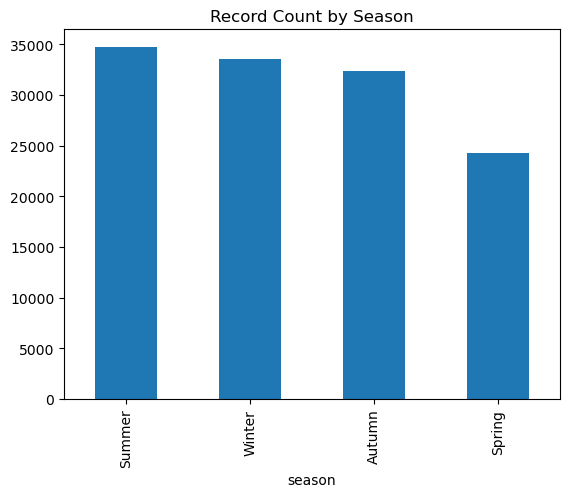

In [25]:
df['season'].value_counts().plot(kind='bar', title="Record Count by Season")

In [26]:
 df.groupby('season')['temperature_celsius'].mean()  # average temperature by season

season
Autumn    21.372878
Spring    22.501191
Summer    26.618793
Winter    15.959798
Name: temperature_celsius, dtype: float64

<Axes: title={'center': 'Average Temperature by Season'}, xlabel='season'>

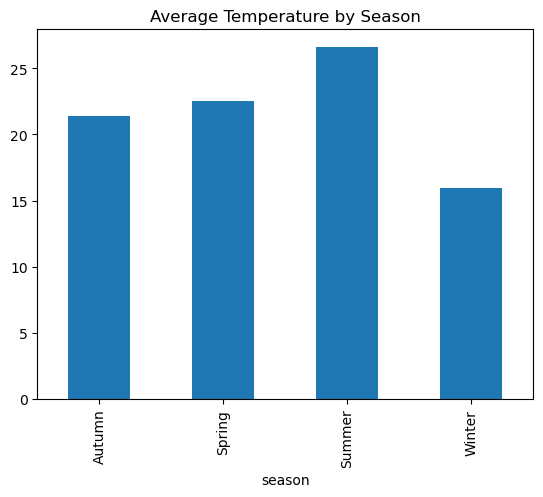

In [27]:
df.groupby('season')['temperature_celsius'].mean().plot(
    kind='bar',
    title="Average Temperature by Season"
)

=== Average Humidity by Season ===
season
Autumn    69.685732
Spring    62.059824
Summer    63.932646
Winter    67.976016
Name: humidity, dtype: float64


=== Average Wind Speed (kph) by Season ===
season
Autumn    11.898830
Spring    13.739265
Summer    13.396753
Winter    13.078072
Name: wind_kph, dtype: float64


=== Average Precipitation (mm) by Season ===
season
Autumn    0.154006
Spring    0.119889
Summer    0.190851
Winter    0.076607
Name: precip_mm, dtype: float64




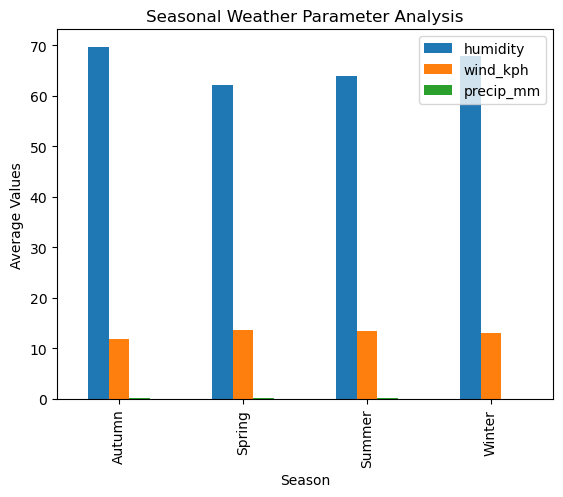

In [28]:
# Seasonal Analysis of Multiple Weather Parameters

print("=== Average Humidity by Season ===")
avg_humidity = df.groupby('season')['humidity'].mean()
print(avg_humidity)
print("\n")


print("=== Average Wind Speed (kph) by Season ===")
avg_wind = df.groupby('season')['wind_kph'].mean()
print(avg_wind)
print("\n")


print("=== Average Precipitation (mm) by Season ===")
avg_precip = df.groupby('season')['precip_mm'].mean()
print(avg_precip)
print("\n")


# Combined visualization
import matplotlib.pyplot as plt

seasonal_avg = df.groupby('season')[['humidity','wind_kph','precip_mm']].mean()

seasonal_avg.plot(kind='bar', title="Seasonal Weather Parameter Analysis")
plt.xlabel("Season")
plt.ylabel("Average Values")
plt.show()

In [29]:
import warnings
warnings.filterwarnings('ignore')

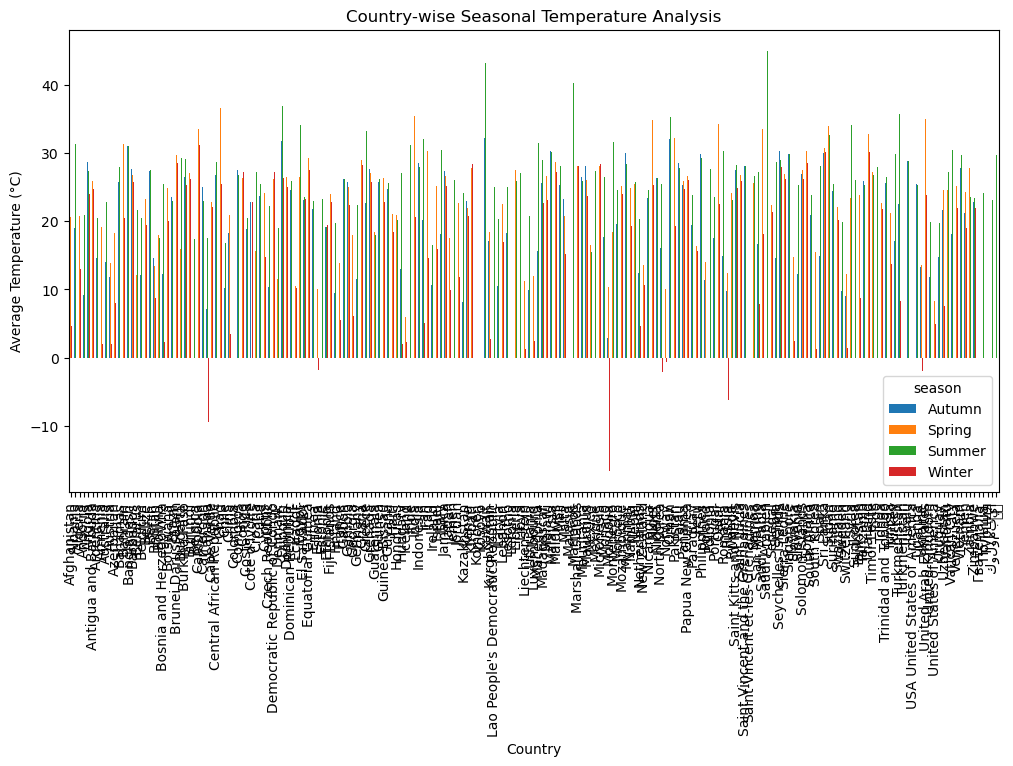

In [30]:
country_season_temp = df.groupby(['country','season'])['temperature_celsius'].mean().unstack()

country_season_temp.plot(kind='bar', figsize=(12,6))

plt.title("Country-wise Seasonal Temperature Analysis")
plt.xlabel("Country")
plt.ylabel("Average Temperature (°C)")
plt.show()

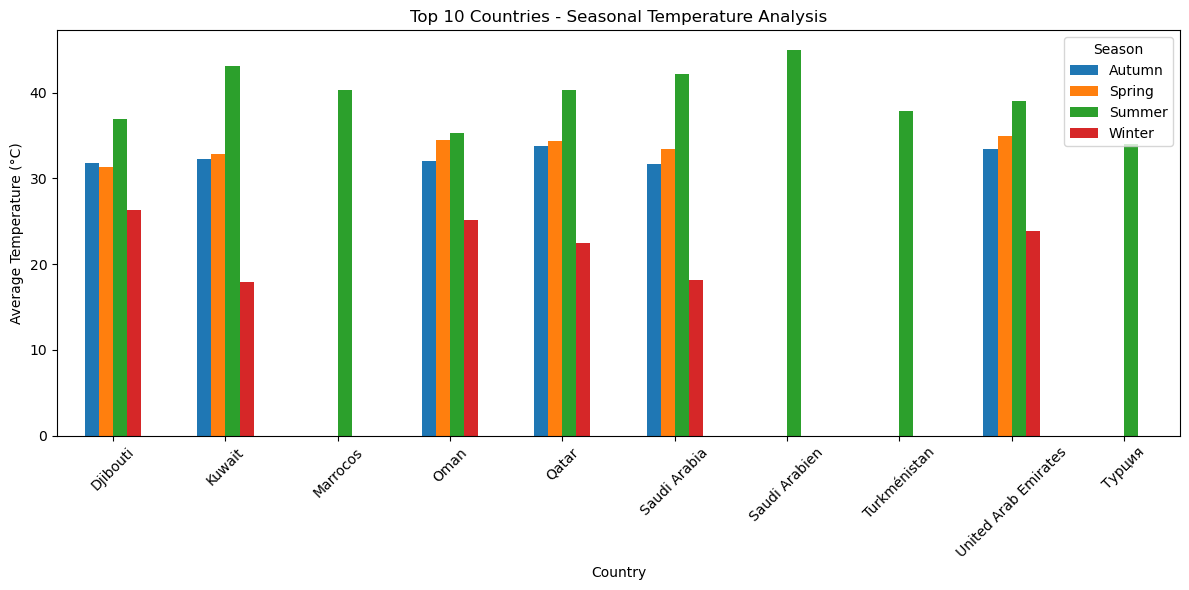

In [31]:
# top 10 countries seasonal temperature analysis

import matplotlib.pyplot as plt

# Step 1: Find top 10 hottest countries based on average temperature
top_countries = df.groupby('country')['temperature_celsius'].mean().nlargest(10).index

# Step 2: Filter the dataset to include only those top 10 countries
filtered_df = df[df['country'].isin(top_countries)]  # keeps only rows where country is in top_counties list

# Step 3: Calculate average temperature for each country in each season
country_season_temp = filtered_df.groupby(['country','season'])['temperature_celsius'].mean().unstack()

# Step 4: Plot the bar chart
country_season_temp.plot(kind='bar', figsize=(12,6))

# Step 5: Add title and labels
plt.title("Top 10 Countries - Seasonal Temperature Analysis")
plt.xlabel("Country")
plt.ylabel("Average Temperature (°C)")

# Step 6: Rotate country names for better readability
plt.xticks(rotation=45)

# Step 7: Show legend (Season names)
plt.legend(title="Season")

# Step 8: Adjust layout to prevent overlap
plt.tight_layout()

# Step 9: Display the chart
plt.show()

In [32]:
# ADVANCED ANALYSIS

In [33]:
'''1. Is there a statistically significant linear correlation between high temperatures
and humidity levels across different climate zones?'''

'1. Is there a statistically significant linear correlation between high temperatures\nand humidity levels across different climate zones?'

In [34]:
# Step 1: Define a function to classify climate zones based on latitude
def get_climate_zone(lat):
    if lat >= 66.5:
        return 'Polar'
    elif 23.5 <= lat < 66.5:
        return 'Temperate'
    elif -23.5 < lat < 23.5:
        return 'Tropical'
    elif -66.5 < lat <= -23.5:
        return 'Temperate (Southern)'
    elif lat <= -66.5:
        return 'Polar (Southern)'
    else:
        return 'Unknown'

# Step 2: Apply the function to the latitude column
df['climate_zone'] = df['latitude'].apply(get_climate_zone)

# Step 3: Check the result
print(df[['country','latitude','climate_zone']].head())

# Step 4: Count of records per climate zone
print(df['climate_zone'].value_counts())

       country  latitude climate_zone
0  Afghanistan     34.52    Temperate
1      Albania     41.33    Temperate
2      Algeria     36.76    Temperate
3      Andorra     42.50    Temperate
4       Angola     -8.84     Tropical
climate_zone
Tropical                62083
Temperate               55962
Temperate (Southern)     6871
Name: count, dtype: int64


In [35]:
# Step 1: Import the Pearson correlation function
from scipy.stats import pearsonr

# Step 2: Loop through each climate zone in the dataset
for zone in df['climate_zone'].unique(): 
    # Subset the data for the zone
    subset = df[df['climate_zone'] == zone]
    
    # Ensure there are enough data points
    if len(subset) > 2:
        # Calculate Pearson correlation and p-value
        corr, p_value = pearsonr(subset['temperature_celsius'], subset['humidity'])
        
        # Print results
        print(f"Climate Zone: {zone}")
        print(f"  Pearson correlation: {corr:.2f}")
        print(f"  p-value: {p_value:.3f}")
        if p_value < 0.05:
            print("  -> Statistically significant correlation")
        else:
            print("  -> Not statistically significant")
        print("-"*50)
    else:
        print(f"Climate Zone: {zone} has too few data points to compute correlation.")

Climate Zone: Temperate
  Pearson correlation: -0.63
  p-value: 0.000
  -> Statistically significant correlation
--------------------------------------------------
Climate Zone: Tropical
  Pearson correlation: -0.28
  p-value: 0.000
  -> Statistically significant correlation
--------------------------------------------------
Climate Zone: Temperate (Southern)
  Pearson correlation: -0.59
  p-value: 0.000
  -> Statistically significant correlation
--------------------------------------------------


In [36]:
'''2.How strongly does wind speed correlate with changes in atmospheric pressure? '''

'2.How strongly does wind speed correlate with changes in atmospheric pressure? '

In [37]:
import pandas as pd
from scipy.stats import pearsonr

# Convert date column to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Sort by time
df = df.sort_values('last_updated')

# Calculate pressure change
df['pressure_change'] = df['pressure_mb'].diff()

# Remove missing values
subset = df[['wind_kph', 'pressure_change']].dropna()

# Calculate correlation
corr, p_value = pearsonr(subset['wind_kph'], subset['pressure_change'])

print("Wind Speed vs Pressure Change")

print(f"Pearson Correlation: {corr:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("-> Statistically Significant Relationship")
else:
    print("-> Not Statistically Significant")

Wind Speed vs Pressure Change
Pearson Correlation: -0.04
P-value: 0.0000
-> Statistically Significant Relationship


In [38]:
'''3.Which variables (e.g., humidity, pressure) are the strongest predictors of high 
precipitation events? '''

'3.Which variables (e.g., humidity, pressure) are the strongest predictors of high \nprecipitation events? '

In [39]:
import pandas as pd
from scipy.stats import pearsonr

# Step 1: Select variables related to precipitation
variables = ['temperature_celsius', 'humidity', 'pressure_mb', 'wind_kph']

# Step 2: Remove missing values
data = df[variables + ['precip_mm']].dropna()

# Step 3: Create a dictionary to store correlation results
results = {}

# Step 4: Loop through each variable
for var in variables:
    
    # Calculate Pearson correlation
    corr, p_value = pearsonr(data[var], data['precip_mm'])
    
    # Store results
    results[var] = (corr, p_value)

# Step 5: Print results
for var, values in results.items():
    corr, p = values
    
    print(f"Variable: {var}")
    print(f"  Correlation with precipitation: {corr:.2f}")
    print(f"  P-value: {p:.4f}")
    
    if p < 0.05:
        print("  -> Statistically Significant")
    else:
        print("  -> Not statistically significant")
        
    print("-"*50)

Variable: temperature_celsius
  Correlation with precipitation: 0.03
  P-value: 0.0000
  -> Statistically Significant
--------------------------------------------------
Variable: humidity
  Correlation with precipitation: 0.17
  P-value: 0.0000
  -> Statistically Significant
--------------------------------------------------
Variable: pressure_mb
  Correlation with precipitation: -0.08
  P-value: 0.0000
  -> Statistically Significant
--------------------------------------------------
Variable: wind_kph
  Correlation with precipitation: 0.01
  P-value: 0.0147
  -> Statistically Significant
--------------------------------------------------


In [40]:
'''4. How have average monthly temperatures shifted globally over the recorded period?  '''

'4. How have average monthly temperatures shifted globally over the recorded period?  '

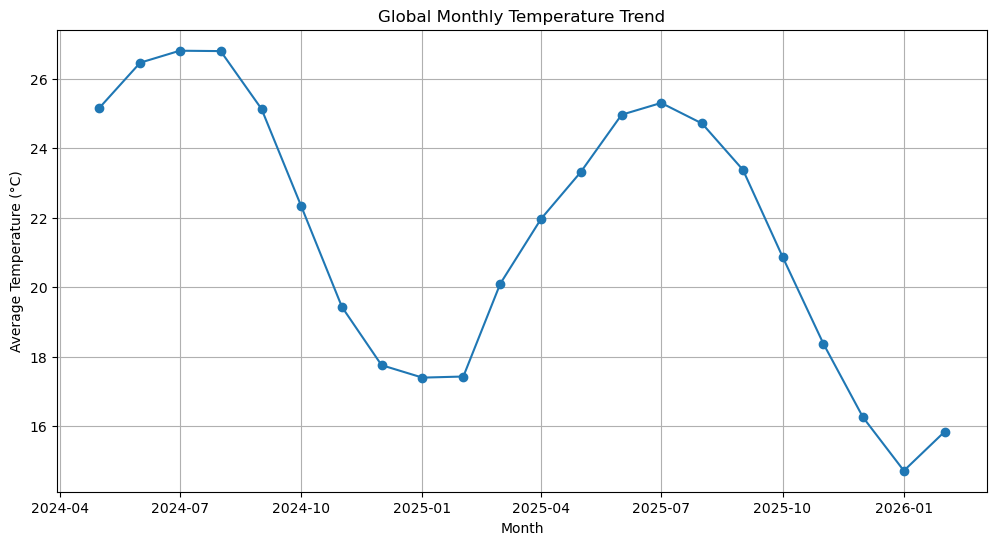

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert date column to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Step 2: Extract year-month
df['year_month'] = df['last_updated'].dt.to_period('M')

# Step 3: Calculate global monthly average temperature
monthly_temp = df.groupby('year_month')['temperature_celsius'].mean()

# Step 4: Convert index to timestamp for plotting
monthly_temp.index = monthly_temp.index.to_timestamp()

# Step 5: Plot the temperature trend
plt.figure(figsize=(12,6))
plt.plot(monthly_temp, marker='o')

plt.title("Global Monthly Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)

plt.show()

In [42]:
'''5.Are there recurring seasonal patterns in precipitation that vary significantly between 
the Northern and Southern Hemispheres? '''

'5.Are there recurring seasonal patterns in precipitation that vary significantly between \nthe Northern and Southern Hemispheres? '

season        Autumn    Spring    Summer    Winter
hemisphere                                        
Northern    0.141174  0.114297  0.176817  0.078241
Southern    0.230122  0.131863  0.244778  0.071217


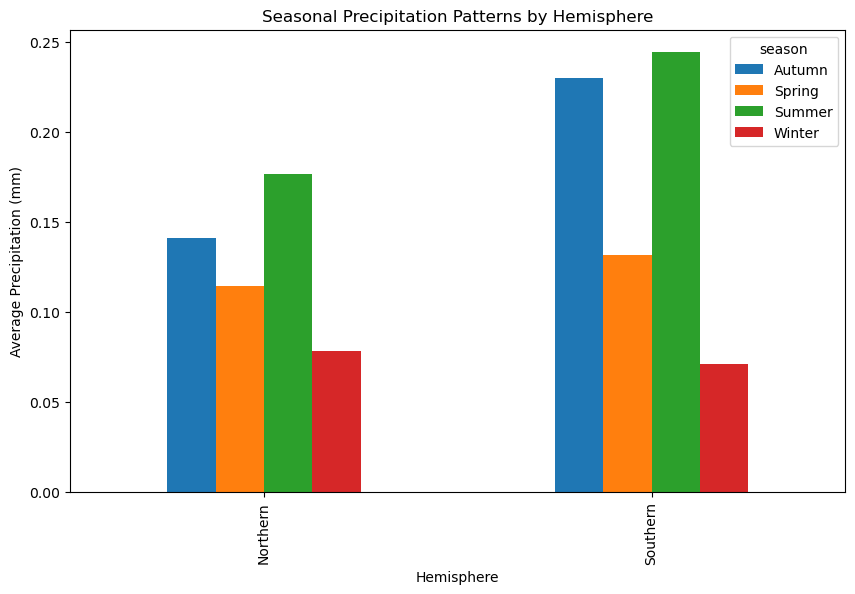

In [43]:
# Step 1: Create hemisphere column
df['hemisphere'] = df['latitude'].apply(
    lambda x: 'Northern' if x >= 0 else 'Southern'
)

# Step 2: Group data by hemisphere and season
precip_pattern = df.groupby(['hemisphere','season'])['precip_mm'].mean()

# Step 3: Convert table for easier visualization
precip_pattern = precip_pattern.unstack()

# Step 4: Print results
print(precip_pattern)

# Step 5: Plot the seasonal precipitation pattern
import matplotlib.pyplot as plt

precip_pattern.plot(kind='bar', figsize=(10,6))

plt.title("Seasonal Precipitation Patterns by Hemisphere")
plt.xlabel("Hemisphere")
plt.ylabel("Average Precipitation (mm)")
plt.show()

In [44]:
'''6. Which regions experience the highest daily temperature swings (diurnal range)?  '''

'6. Which regions experience the highest daily temperature swings (diurnal range)?  '

In [45]:
# Step 1: Calculate diurnal temperature range
df['diurnal_range'] = df['temperature_celsius'] - df['feels_like_celsius']

# Step 2: Convert to absolute value
df['diurnal_range'] = df['diurnal_range'].abs()

# Step 3: Calculate average diurnal range by country
region_dtr = df.groupby('country')['diurnal_range'].mean()

# Step 4: Sort regions by highest temperature swing
region_dtr = region_dtr.sort_values(ascending=False)

# Step 5: Display top 10 regions
print(region_dtr.head(10))

country
Sri Lanka             6.623245
Brunei Darussalam     6.106240
Malaysia              5.936604
Singapore             5.665109
Seychelles Islands    5.091108
Philippines           5.066303
Jamaica               4.526176
Tuvalu                4.401402
Solomon Islands       4.340810
Marshall Islands      4.270405
Name: diurnal_range, dtype: float64


In [46]:
'''7. How do average wind speeds in coastal regions compare to inland or mountainous 
climate zones? '''

'7. How do average wind speeds in coastal regions compare to inland or mountainous \nclimate zones? '

In [47]:
# Calculate average wind speed for each climate zone
avg_wind_speed = df.groupby('climate_zone')['wind_kph'].mean()

# Sort from highest to lowest
avg_wind_speed = avg_wind_speed.sort_values(ascending=False)

# Display result
print("Average Wind Speed by Climate Zone")
print(avg_wind_speed)

Average Wind Speed by Climate Zone
climate_zone
Temperate               13.073214
Tropical                12.935773
Temperate (Southern)    12.793072
Name: wind_kph, dtype: float64


In [48]:
'''8. Which specific countries or continents are currently showing the highest rate of 
temperature increase? '''

'8. Which specific countries or continents are currently showing the highest rate of \ntemperature increase? '

In [49]:
import pandas as pd

# Convert date column to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Extract year
df['year'] = df['last_updated'].dt.year

# Calculate average yearly temperature for each country
country_year_temp = df.groupby(['country', 'year'])['temperature_celsius'].mean().reset_index()

# Calculate temperature increase for each country
temp_trend = country_year_temp.groupby('country')['temperature_celsius'].agg(['first','last'])

# Calculate temperature change
temp_trend['temp_increase'] = temp_trend['last'] - temp_trend['first']

# Sort countries by highest increase
top_warming_countries = temp_trend.sort_values(by='temp_increase', ascending=False)

# Display top 10
print(top_warming_countries.head(10))

                  first       last  temp_increase
country                                          
Australia      9.911790  27.943750      18.031960
Chile          9.398678  17.641667       8.242988
Argentina     13.177632  21.127083       7.949452
Uruguay       13.151528  19.825000       6.673472
New Zealand   12.035808  17.960417       5.924609
Vanuatu       23.385965  28.908333       5.522368
Tonga         22.747598  28.135417       5.387818
Peru          16.539823  21.797917       5.258094
Fiji Islands  23.397817  27.827083       4.429267
Mauritius     25.015284  28.839583       3.824299


In [50]:
'''9. Which geographic regions are identified as "high-precipitation zones" during specific 
months? '''

'9. Which geographic regions are identified as "high-precipitation zones" during specific \nmonths? '

In [51]:
import pandas as pd

# Convert date column to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Extract month
df['month'] = df['last_updated'].dt.month

# Calculate precipitation statistics
mean_precip = df['precip_mm'].mean()
std_precip = df['precip_mm'].std()

# Define threshold for high precipitation
threshold = mean_precip + std_precip

# Filter high precipitation events
high_precip = df[df['precip_mm'] > threshold]

# Group by region and month
high_precip_zones = high_precip.groupby(['country','month'])['precip_mm'].mean().reset_index()

# Sort by precipitation
high_precip_zones = high_precip_zones.sort_values(by='precip_mm', ascending=False)

# Display top regions
print(high_precip_zones.head(10))

                           country  month  precip_mm
282                          Congo      3  19.310000
331   Democratic Republic of Congo      3  17.260000
1086                        Serbia      6  13.880000
597                        Jamaica     11  12.945000
608                          Japan     11  11.970000
359             Dominican Republic      5  11.880000
596                        Jamaica     10  11.385000
1389                     Venezuela      8  10.990000
66                       Australia      8   9.890000
454                         Gambia     10   9.036667


In [52]:
'''10. What are the top 1% of extreme wind speed events recorded, and where did they 
occur? '''

'10. What are the top 1% of extreme wind speed events recorded, and where did they \noccur? '

In [53]:
import numpy as np

# Step 1: Calculate the 99th percentile wind speed
threshold = np.percentile(df['wind_kph'], 99)

# Step 2: Filter extreme wind events
extreme_wind = df[df['wind_kph'] >= threshold]

# Step 3: Select important columns
extreme_wind_events = extreme_wind[['country','location_name','wind_kph','last_updated']]

# Step 4: Sort by wind speed
extreme_wind_events = extreme_wind_events.sort_values(by='wind_kph', ascending=False)

# Step 5: Display top extreme events
print("Top 1% Extreme Wind Speed Events")
print(extreme_wind_events.head(10))

Top 1% Extreme Wind Speed Events
                     country   location_name  wind_kph        last_updated
7601                 Burundi       Bujumbura    2963.2 2024-06-23 15:45:00
7248                Ethiopia     Addis Ababa     272.2 2024-06-21 16:30:00
1193                 Burundi       Bujumbura     258.8 2024-05-21 16:45:00
8675   Saint Kitts and Nevis      Basseterre     205.9 2024-06-28 09:15:00
834             Fiji Islands            Suva     172.1 2024-05-20 02:00:00
51526                Iceland  Vestmannaeyjar      91.1 2025-02-06 10:15:00
9129                Barbados      Bridgetown      81.0 2024-07-01 09:15:00
19892                 Norway            Oslo      78.1 2024-08-27 14:15:00
35380                Iceland  Vestmannaeyjar      76.7 2024-11-15 09:00:00
22816                 Norway            Oslo      76.0 2024-09-11 14:15:00


In [54]:
'''11. Can we identify specific dates where temperatures deviated by more than two 
standard deviations from the historical mean for a region?  '''

'11. Can we identify specific dates where temperatures deviated by more than two \nstandard deviations from the historical mean for a region?  '

In [55]:
import pandas as pd

# Step 1: Calculate mean temperature for each country
mean_temp = df.groupby('country')['temperature_celsius'].transform('mean')

# Step 2: Calculate standard deviation for each country
std_temp = df.groupby('country')['temperature_celsius'].transform('std')

# Step 3: Calculate upper and lower anomaly thresholds
df['upper_limit'] = mean_temp + (2 * std_temp)
df['lower_limit'] = mean_temp - (2 * std_temp)

# Step 4: Identify anomalies
df['temperature_anomaly'] = (
    (df['temperature_celsius'] > df['upper_limit']) |
    (df['temperature_celsius'] < df['lower_limit'])
)

# Step 5: Extract anomaly records
anomalies = df[df['temperature_anomaly'] == True]

# Step 6: Display important columns
print(anomalies[['country','location_name','temperature_celsius','last_updated']].head(10))

       country   location_name  temperature_celsius        last_updated
110     Mexico     Mexico City                 20.8 2024-05-16 02:45:00
84     Jamaica  Norman Gardens                 21.9 2024-05-16 03:45:00
269   Honduras     Tegucigalpa                 25.0 2024-05-16 08:00:00
212     Belize        Belmopan                 30.0 2024-05-16 08:00:00
319  Nicaragua         Managua                 28.0 2024-05-16 08:15:00
279    Jamaica  Norman Gardens                 31.0 2024-05-16 09:00:00
245    Ecuador           Quito                 16.2 2024-05-16 09:00:00
329     Panama     Panama City                 28.0 2024-05-16 09:15:00
262    Grenada  Saint George's                 31.0 2024-05-16 10:00:00
266     Guyana      Georgetown                 29.0 2024-05-16 10:00:00


In [56]:
'''12. Are there regions experiencing "flash"
precipitation events that fall outside of 
expected seasonal trends? '''

'12. Are there regions experiencing "flash"\nprecipitation events that fall outside of \nexpected seasonal trends? '

In [57]:
import pandas as pd

# Step 1: Calculate seasonal average precipitation
season_avg = df.groupby('season')['precip_mm'].mean()

# Step 2: Calculate seasonal standard deviation
season_std = df.groupby('season')['precip_mm'].std()

# Step 3: Map values back to dataframe
df['season_avg_precip'] = df['season'].map(season_avg)
df['season_std_precip'] = df['season'].map(season_std)

# Step 4: Define flash precipitation threshold
df['flash_threshold'] = df['season_avg_precip'] + (2 * df['season_std_precip'])

# Step 5: Detect flash events with additional rainfall condition
df['flash_event'] = (
    (df['precip_mm'] > df['flash_threshold']) &
    (df['precip_mm'] > 10)  # minimum rainfall threshold
)

# Step 6: Extract flash precipitation events
flash_events = df[df['flash_event']]

# Step 7: Display results
print("Flash Precipitation Events")
print(flash_events[['country','location_name','season','precip_mm','last_updated']].head(10))

Flash Precipitation Events
                 country location_name  season  precip_mm        last_updated
935      Solomon Islands       Honiara  Autumn      13.05 2024-05-20 01:15:00
3725            Bulgaria         Sofia  Summer      18.90 2024-06-03 17:15:00
6286   Equatorial Guinea        Malabo  Summer      16.92 2024-06-16 14:45:00
6770        Sierra Leone      Freetown  Summer      10.66 2024-06-18 14:00:00
7243         El Salvador  San Salvador  Summer      19.20 2024-06-21 07:30:00
8488              Serbia      Belgrade  Summer      13.88 2024-06-27 15:15:00
10384          Lithuania       Vilnius  Summer      14.41 2024-07-07 16:00:00
13085        Philippines        Manila  Summer      13.88 2024-07-23 20:30:00
16285             Canada        Ottawa  Summer      10.23 2024-08-09 08:30:00
16603       Sierra Leone      Freetown  Summer      10.49 2024-08-10 12:30:00


In [58]:
'''13.  In which specific climate zones does the correlation between temperature and 
humidity break down (become inverse), and what does this suggest about local "dry 
heat" vs. "humid heat" trends? '''

'13.  In which specific climate zones does the correlation between temperature and \nhumidity break down (become inverse), and what does this suggest about local "dry \nheat" vs. "humid heat" trends? '

In [59]:
from scipy.stats import pearsonr

# Step 1: Get unique climate zones
zones = df['climate_zone'].unique()

# Step 2: Loop through each zone
for zone in zones:
    
    # Step 3: Filter data for that climate zone
    subset = df[df['climate_zone'] == zone]
    
    # Step 4: Ensure enough data points
    if len(subset) > 2:
        
        # Step 5: Calculate correlation
        corr, p_value = pearsonr(
            subset['temperature_celsius'],
            subset['humidity']
        )
        
        # Step 6: Print results
        print("Climate Zone:", zone)
        print("Correlation:", round(corr,2))
        print("P-value:", round(p_value,4))
        
        # Step 7: Check inverse relationship
        if corr < 0:
            print("→ Inverse correlation detected (Dry heat trend)")
        else:
            print("→ Positive correlation (Humid heat trend)")
            
        print("-"*50)

Climate Zone: Temperate
Correlation: -0.63
P-value: 0.0
→ Inverse correlation detected (Dry heat trend)
--------------------------------------------------
Climate Zone: Tropical
Correlation: -0.28
P-value: 0.0
→ Inverse correlation detected (Dry heat trend)
--------------------------------------------------
Climate Zone: Temperate (Southern)
Correlation: -0.59
P-value: 0.0
→ Inverse correlation detected (Dry heat trend)
--------------------------------------------------


In [60]:

'''14. Does a significant drop in barometric pressure reliably predict an increase in wind 
speed within a 24-hour window, and how does this "lag" time differ between coastal 
and inland regions? '''


'14. Does a significant drop in barometric pressure reliably predict an increase in wind \nspeed within a 24-hour window, and how does this "lag" time differ between coastal \nand inland regions? '

In [61]:
import pandas as pd

# Step 1: Convert time column to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Step 2: Sort data by time
df = df.sort_values('last_updated')

# Step 3: Calculate pressure change
df['pressure_change'] = df['pressure_mb'].diff()

# Step 4: Calculate wind change
df['wind_change'] = df['wind_kph'].diff()

# Step 5: Identify pressure drops
df['pressure_drop'] = df['pressure_change'] < -2

# Step 6: Identify wind increases
df['wind_increase'] = df['wind_change'] > 2

# Step 7: Check if wind increases within next 24 hours
df['future_wind'] = df['wind_kph'].shift(-1)

# Step 8: Calculate lag relationship
df['wind_response'] = df['future_wind'] > df['wind_kph']

# Step 9: Extract events
events = df[df['pressure_drop'] == True]

print(events[['country','pressure_mb','wind_kph','last_updated']].head(10))

         country  pressure_mb  wind_kph        last_updated
124    Nicaragua       1009.0       5.8 2024-05-16 02:45:00
110       Mexico       1013.0      10.8 2024-05-16 02:45:00
134       Panama       1010.0       3.6 2024-05-16 03:45:00
137         Peru       1013.0      11.9 2024-05-16 03:45:00
71        Guyana       1011.0       3.6 2024-05-16 04:45:00
167     Suriname       1010.0       7.6 2024-05-16 05:45:00
247  El Salvador       1011.0       6.8 2024-05-16 08:00:00
235   Costa Rica       1017.0       9.0 2024-05-16 08:00:00
212       Belize       1010.0      13.0 2024-05-16 08:00:00
329       Panama       1011.0       9.0 2024-05-16 09:15:00


In [62]:
'''15. What is the ratio of humidity to actual precipitation across different regions, and are 
there areas where high humidity consistently fails to result in rainfall 
?  '''

'15. What is the ratio of humidity to actual precipitation across different regions, and are \nthere areas where high humidity consistently fails to result in rainfall \n?  '

In [63]:
import numpy as np

# Step 1: Avoid division by zero
df['precip_mm'] = df['precip_mm'].replace(0, np.nan)

# Step 2: Calculate humidity to precipitation ratio
df['humidity_precip_ratio'] = df['humidity'] / df['precip_mm']

# Step 3: Group by country (or region)
region_ratio = df.groupby('country')['humidity_precip_ratio'].mean()

# Step 4: Sort regions by highest ratio
region_ratio = region_ratio.sort_values(ascending=False)

# Step 5: Display top regions
print(region_ratio.head(10))

country
Peru             7018.731369
Angola           4146.730301
Cote d'Ivoire    4101.811451
Somalia          4054.709382
Honduras         4048.822868
Colombia         4000.000000
Cape Verde       3715.270225
Ghana            3710.417941
Kiribati         3459.326845
Belize           3376.362326
Name: humidity_precip_ratio, dtype: float64


In [64]:
'''16. How often do "compound extremes"—such as simultaneous high heat and high wind 
speeds—occur in the dataset, and has the frequency of these combined events 
increased over the recorded period? '''


'16. How often do "compound extremes"—such as simultaneous high heat and high wind \nspeeds—occur in the dataset, and has the frequency of these combined events \nincreased over the recorded period? '

In [65]:
import numpy as np

# Step 1: Convert date column
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Step 2: Extract year
df['year'] = df['last_updated'].dt.year

# Step 3: Calculate extreme thresholds
temp_threshold = np.percentile(df['temperature_celsius'], 95)
wind_threshold = np.percentile(df['wind_kph'], 95)

# Step 4: Identify extreme temperature
df['extreme_temp'] = df['temperature_celsius'] >= temp_threshold

# Step 5: Identify extreme wind
df['extreme_wind'] = df['wind_kph'] >= wind_threshold

# Step 6: Identify compound extreme events
df['compound_event'] = df['extreme_temp'] & df['extreme_wind']

# Step 7: Count compound events per year
compound_trend = df.groupby('year')['compound_event'].sum()

# Step 8: Display results
print(compound_trend)

year
2024    188
2025    189
2026      0
Name: compound_event, dtype: int64


In [66]:
'''17. If we define "extreme" as being 3 standard deviations 3 from the regional mean, 
σ

which continents are seeing the fastest growth in the number of these outliers for 
temperature and precipitation?  '''


'17. If we define "extreme" as being 3 standard deviations 3 from the regional mean, \nσ\n\nwhich continents are seeing the fastest growth in the number of these outliers for \ntemperature and precipitation?  '

In [67]:
!pip install unidecode

        continent  year  temp_outlier  precip_outlier  temp_growth  \
0          Africa  2024           109              41          NaN   
1          Africa  2025           159              55         50.0   
2          Africa  2026            57               1       -102.0   
3            Asia  2024            77              44          NaN   
4            Asia  2025           165              59         88.0   
5            Asia  2026           102               3        -63.0   
6          Europe  2024             0              52          NaN   
7          Europe  2025             0              62          0.0   
8          Europe  2026            60              18         60.0   
9   North America  2024            48              29          NaN   
10  North America  2025           182              25        134.0   
11  North America  2026            56               0       -126.0   
12        Oceania  2024            86              16          NaN   
13        Oceania  2

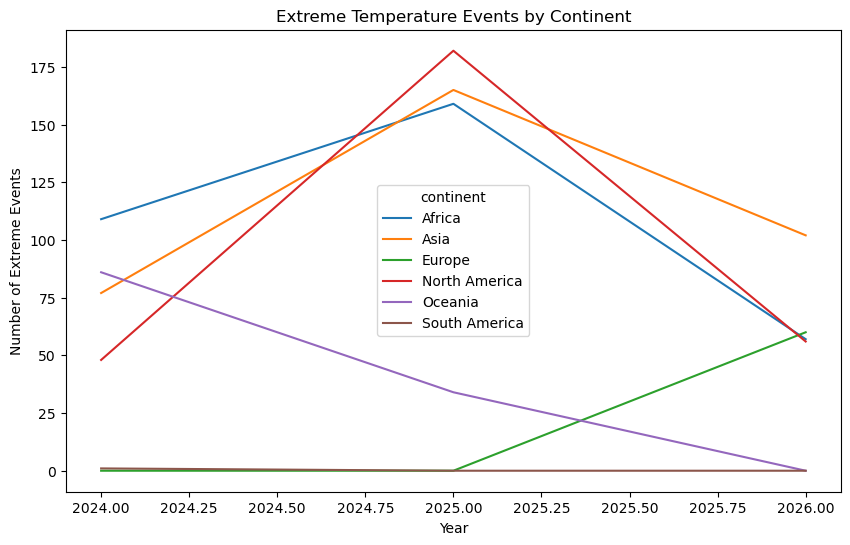

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode
import pycountry
import pycountry_convert as pc

# -----------------------------
# 1. Clean country names
# -----------------------------
df["country_clean"] = df["country"].astype(str).apply(unidecode)
df["country_clean"] = df["country_clean"].str.strip()
df["country_clean"] = df["country_clean"].str.title()

# -----------------------------
# 2. Fix common country variations
# -----------------------------
country_fix = {
    "Usa": "United States",
    "Uk": "United Kingdom",
    "Korea South": "South Korea",
    "Korea North": "North Korea",
    "Cote D Ivoire": "Ivory Coast",
    "Russian Federation": "Russia",
    "Uae": "United Arab Emirates"
}

df["country_clean"] = df["country_clean"].replace(country_fix)

# -----------------------------
# 3. Convert country -> continent
# -----------------------------
def get_continent(country_name):
    try:
        country_code = pycountry.countries.lookup(country_name).alpha_2
        continent_code = pc.country_alpha2_to_continent_code(country_code)

        continent_map = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania"
        }

        return continent_map[continent_code]

    except:
        return None

df["continent"] = df["country_clean"].apply(get_continent)

# -----------------------------
# 4. Remove rows with unknown continent
# -----------------------------
df = df.dropna(subset=["continent"])

# -----------------------------
# 5. Detect temperature outliers (3σ rule)
# -----------------------------
temp_mean = df.groupby("continent")["temperature_celsius"].transform("mean")
temp_std = df.groupby("continent")["temperature_celsius"].transform("std")

df["temp_outlier"] = abs(df["temperature_celsius"] - temp_mean) > (3 * temp_std)

# -----------------------------
# 6. Detect precipitation outliers
# -----------------------------
precip_mean = df.groupby("continent")["precip_mm"].transform("mean")
precip_std = df.groupby("continent")["precip_mm"].transform("std")

df["precip_outlier"] = abs(df["precip_mm"] - precip_mean) > (3 * precip_std)

# -----------------------------
# 7. Count extreme events per continent per year
# -----------------------------
continent_extremes = df.groupby(["continent","year"])[
    ["temp_outlier","precip_outlier"]
].sum().reset_index()

# -----------------------------
# 8. Growth calculation
# -----------------------------
continent_extremes["temp_growth"] = continent_extremes.groupby("continent")["temp_outlier"].diff()
continent_extremes["precip_growth"] = continent_extremes.groupby("continent")["precip_outlier"].diff()

print(continent_extremes)

# -----------------------------
# 9. Visualization
# -----------------------------
pivot_temp = continent_extremes.pivot(index="year", columns="continent", values="temp_outlier")

pivot_temp.plot(figsize=(10,6))
plt.title("Extreme Temperature Events by Continent")
plt.xlabel("Year")
plt.ylabel("Number of Extreme Events")
plt.show()

In [69]:
'''18. After a peak "extreme weather event" (like a storm or heatwave), what is the average 
"recovery time" for a region to return to its 30-day rolling mean temperature? '''


'18. After a peak "extreme weather event" (like a storm or heatwave), what is the average \n"recovery time" for a region to return to its 30-day rolling mean temperature? '

In [70]:
import pandas as pd
import numpy as np

# --------------------------------------
# 1. Create datetime column from year, month, day, hour
# --------------------------------------
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

# --------------------------------------
# 2. Sort dataset for proper time order
# --------------------------------------
df = df.sort_values(["country", "datetime"]).reset_index(drop=True)

# --------------------------------------
# 3. Calculate 30-observation rolling mean temperature
# --------------------------------------
df["rolling_mean_30"] = (
    df.groupby("country")["temperature_celsius"]
    .transform(lambda x: x.rolling(window=30, min_periods=1).mean())
)

# --------------------------------------
# 4. Detect extreme temperature events using 3-sigma rule
# --------------------------------------
temp_mean = df.groupby("country")["temperature_celsius"].transform("mean")
temp_std = df.groupby("country")["temperature_celsius"].transform("std")

df["extreme_event"] = abs(df["temperature_celsius"] - temp_mean) > (3 * temp_std)

# --------------------------------------
# 5. Find recovery time after extreme events
# --------------------------------------
recovery_records = []

for country in df["country"].unique():

    sub = df[df["country"] == country].reset_index(drop=True)

    for i in range(len(sub)):

        if sub.loc[i, "extreme_event"]:

            event_time = sub.loc[i, "datetime"]

            for j in range(i + 1, len(sub)):

                temp = sub.loc[j, "temperature_celsius"]
                rolling = sub.loc[j, "rolling_mean_30"]

                # Recovery condition: temp close to rolling mean
                if abs(temp - rolling) < 1:

                    recovery_days = (
                        sub.loc[j, "datetime"] - event_time
                    ).total_seconds() / 86400

                    recovery_records.append({
                        "country": country,
                        "recovery_days": recovery_days
                    })

                    break

# --------------------------------------
# 6. Convert results to dataframe
# --------------------------------------
recovery_df = pd.DataFrame(recovery_records)

# --------------------------------------
# 7. Average recovery time per country
# --------------------------------------
avg_recovery = (
    recovery_df.groupby("country")["recovery_days"]
    .mean()
    .reset_index()
)

# --------------------------------------
# 8. Show results
# --------------------------------------
print(avg_recovery.head())

      country  recovery_days
0   Australia       1.000000
1     Bahamas       4.979167
2  Bangladesh       4.000000
3    Barbados       1.000000
4     Belarus       6.489583


In [71]:
'''19. Is the transition period between seasons (e.g., Winter to Spring) becoming shorter or \nmore volatile? You can measure this by the "rate of change" in weekly average \ntemperatures.''' 

'19. Is the transition period between seasons (e.g., Winter to Spring) becoming shorter or \nmore volatile? You can measure this by the "rate of change" in weekly average \ntemperatures.'

       country  season_volatility
0  Afghanistan           3.080930
1      Albania           3.178405
2      Algeria           2.521520
3      Andorra           3.557434
4       Angola           0.961005


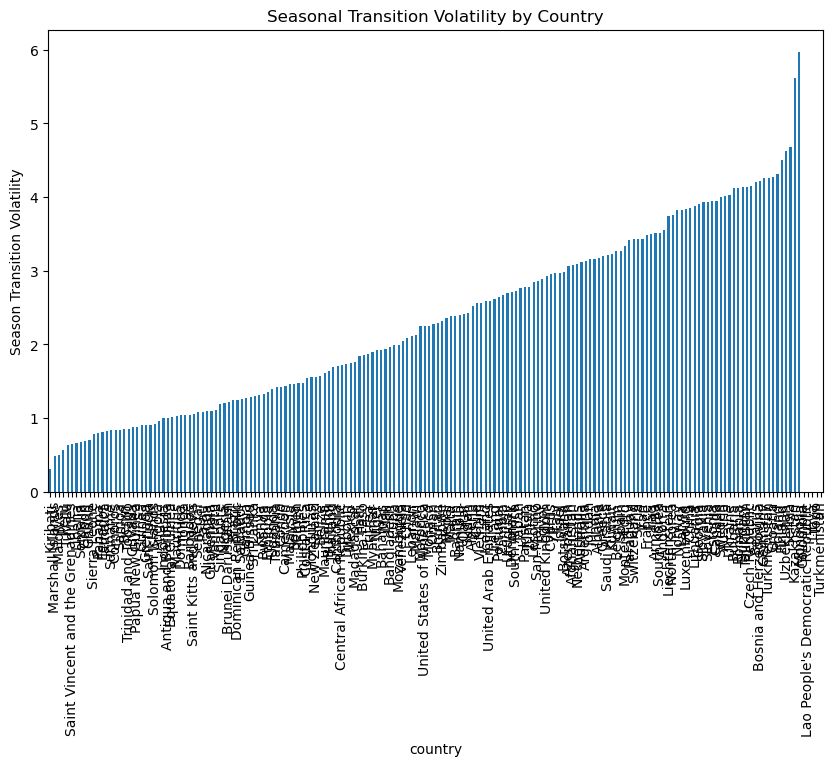

In [72]:
import pandas as pd
import numpy as np

# ----------------------------------
# 1. Create datetime column
# ----------------------------------
df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])

# ----------------------------------
# 2. Create week column
# ----------------------------------
df["week"] = df["datetime"].dt.isocalendar().week
df["year"] = df["datetime"].dt.year

# ----------------------------------
# 3. Calculate weekly average temperature
# ----------------------------------
weekly_temp = df.groupby(["country","year","week"])["temperature_celsius"].mean().reset_index()

# ----------------------------------
# 4. Sort values
# ----------------------------------
weekly_temp = weekly_temp.sort_values(["country","year","week"])

# ----------------------------------
# 5. Calculate rate of change
# ----------------------------------
weekly_temp["temp_change"] = weekly_temp.groupby("country")["temperature_celsius"].diff()

# ----------------------------------
# 6. Measure volatility
# ----------------------------------
volatility = weekly_temp.groupby("country")["temp_change"].std().reset_index()

volatility = volatility.rename(columns={"temp_change":"season_volatility"})

print(volatility.head())

volatility.sort_values("season_volatility").plot(
    x="country",
    y="season_volatility",
    kind="bar",
    figsize=(10,6),
    legend=False
)

plt.ylabel("Season Transition Volatility")
plt.title("Seasonal Transition Volatility by Country")
plt.show()

In [73]:
'''20. Is the gap between daily maximum and minimum temperatures (Diurnal Temperature 
Range) narrowing globally, and does this correlate with increased cloud cover or 
humidity in those regions?  '''


'20. Is the gap between daily maximum and minimum temperatures (Diurnal Temperature \nRange) narrowing globally, and does this correlate with increased cloud cover or \nhumidity in those regions?  '

In [74]:
import pandas as pd
import numpy as np

# ---------------------------------
# 1. Create datetime column
# ---------------------------------
df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])

# ---------------------------------
# 2. Extract date
# ---------------------------------
df["date"] = df["datetime"].dt.date

# ---------------------------------
# 3. Calculate daily max and min temperature
# ---------------------------------
daily_temp = df.groupby(["country","date"])["temperature_celsius"].agg(["max","min"]).reset_index()

# ---------------------------------
# 4. Compute Diurnal Temperature Range
# ---------------------------------
daily_temp["DTR"] = daily_temp["max"] - daily_temp["min"]

# ---------------------------------
# 5. Calculate daily humidity and cloud averages
# ---------------------------------
daily_atmos = df.groupby(["country","date"])[["humidity","cloud"]].mean().reset_index()

# ---------------------------------
# 6. Merge datasets
# ---------------------------------
daily_data = pd.merge(daily_temp, daily_atmos, on=["country","date"])

# ---------------------------------
# 7. Global DTR trend
# ---------------------------------
global_dtr = daily_data["DTR"].mean()

print("Average Global DTR:", global_dtr)

# ---------------------------------
# 8. Correlation analysis
# ---------------------------------
corr_cloud = daily_data["DTR"].corr(daily_data["cloud"])
corr_humidity = daily_data["DTR"].corr(daily_data["humidity"])

print("Correlation between DTR and Cloud Cover:", corr_cloud)
print("Correlation between DTR and Humidity:", corr_humidity)

Average Global DTR: 0.22033873782632676
Correlation between DTR and Cloud Cover: -0.01213791357063251
Correlation between DTR and Humidity: -0.054718880491280736


In [75]:
'''21. Are weather patterns (like 5+ day streaks of above-average heat) becoming more 
"persistent" over time compared to historical fluctuations in the dataset? '''


'21. Are weather patterns (like 5+ day streaks of above-average heat) becoming more \n"persistent" over time compared to historical fluctuations in the dataset? '

In [76]:
import pandas as pd
import numpy as np

# --------------------------------
# 1. Create datetime column
# --------------------------------
df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])

# --------------------------------
# 2. Extract date
# --------------------------------
df["date"] = df["datetime"].dt.date

# --------------------------------
# 3. Daily average temperature
# --------------------------------
daily_temp = df.groupby(["country","date"])["temperature_celsius"].mean().reset_index()

# --------------------------------
# 4. Long-term average temperature per country
# --------------------------------
country_mean = daily_temp.groupby("country")["temperature_celsius"].mean()

daily_temp["avg_temp"] = daily_temp["country"].map(country_mean)

# --------------------------------
# 5. Detect above-average heat days
# --------------------------------
daily_temp["above_avg"] = daily_temp["temperature_celsius"] > daily_temp["avg_temp"]

# --------------------------------
# 6. Detect streak groups
# --------------------------------
daily_temp["streak_id"] = (
    daily_temp["above_avg"] != daily_temp.groupby("country")["above_avg"].shift()
).cumsum()

# --------------------------------
# 7. Calculate streak lengths
# --------------------------------
streak_lengths = (
    daily_temp[daily_temp["above_avg"]]
    .groupby(["country","streak_id"])
    .size()
    .reset_index(name="streak_length")
)

# --------------------------------
# 8. Keep streaks ≥ 5 days
# --------------------------------
heat_streaks = streak_lengths[streak_lengths["streak_length"] >= 5]

# --------------------------------
# 9. Add year for trend analysis
# --------------------------------
daily_temp["year"] = pd.to_datetime(daily_temp["date"]).dt.year

heat_streaks = heat_streaks.merge(
    daily_temp[["country","streak_id","year"]].drop_duplicates(),
    on=["country","streak_id"]
)

# --------------------------------
# 10. Count streaks per year
# --------------------------------
streak_trend = heat_streaks.groupby("year").size().reset_index(name="heat_streak_count")

print(streak_trend.head())

   year  heat_streak_count
0  2024                857
1  2025               1181
2  2026                 91


In [77]:
'''22. Are the weather profiles (temperature/humidity signatures) of certain regions 
beginning to more closely resemble a different climate zone than they were 
historically categorized in? '''


'22. Are the weather profiles (temperature/humidity signatures) of certain regions \nbeginning to more closely resemble a different climate zone than they were \nhistorically categorized in? '

In [78]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Sort dataset by time
# -----------------------------
df = df.sort_values("last_updated_epoch")

# -----------------------------
# 2. Split dataset
# -----------------------------
midpoint = int(len(df) * 0.5)

historical = df.iloc[:midpoint]
recent = df.iloc[midpoint:]

# -----------------------------
# 3. Regional weather profiles
# -----------------------------
hist_profile = historical.groupby("location_name")[["temperature_celsius","humidity"]].mean()

recent_profile = recent.groupby("location_name")[["temperature_celsius","humidity"]].mean()

# -----------------------------
# 4. Keep only common locations
# -----------------------------
common_locations = hist_profile.index.intersection(recent_profile.index)

hist_profile = hist_profile.loc[common_locations]
recent_profile = recent_profile.loc[common_locations]

# -----------------------------
# 5. Normalize features
# -----------------------------
scaler = StandardScaler()

hist_scaled = scaler.fit_transform(hist_profile)
recent_scaled = scaler.transform(recent_profile)

# -----------------------------
# 6. KMeans clustering
# -----------------------------
kmeans = KMeans(n_clusters=4, random_state=42)

hist_clusters = kmeans.fit_predict(hist_scaled)

# -----------------------------
# 7. Predict recent clusters
# -----------------------------
recent_clusters = kmeans.predict(recent_scaled)

# -----------------------------
# 8. Compare clusters
# -----------------------------
comparison = pd.DataFrame({
    "historical_cluster": hist_clusters,
    "recent_cluster": recent_clusters
}, index=common_locations)

# -----------------------------
# 9. Detect climate shifts
# -----------------------------
comparison["climate_shift"] = comparison["historical_cluster"] != comparison["recent_cluster"]

# -----------------------------
# 10. Show results
# -----------------------------
climate_shift_regions = comparison[comparison["climate_shift"]]

print("Regions with climate profile shifts:")
print(climate_shift_regions)

Regions with climate profile shifts:
                   historical_cluster  recent_cluster  climate_shift
location_name                                                       
'S Gravenjansdijk                   2               3           True
Abuja                               1               0           True
Antananarivo                        1               3           True
Asmara                              3               1           True
Athens                              1               3           True
Aurora                              3               2           True
Bamako                              1               0           True
Bangui                              1               0           True
Banjul                              1               0           True
Belgrade                            3               2           True
Bratislava                          3               2           True
Bucharest                           3               2           Tr

In [79]:
'''23. Which geographic regions show the highest "standard deviation" in their weather 
variables, making them the most unpredictable for local decision-making and 
agriculture? '''

'23. Which geographic regions show the highest "standard deviation" in their weather \nvariables, making them the most unpredictable for local decision-making and \nagriculture? '

In [80]:
import pandas as pd

# -----------------------------
# 1. Select important weather variables
# -----------------------------
weather_vars = [
    "temperature_celsius",
    "humidity",
    "precip_mm",
    "wind_kph",
    "pressure_mb"
]

# -----------------------------
# 2. Calculate standard deviation per region
# -----------------------------
region_variability = df.groupby("location_name")[weather_vars].std()

# -----------------------------
# 3. Create overall variability score
# -----------------------------
region_variability["overall_variability"] = region_variability.mean(axis=1)

# -----------------------------
# 4. Sort regions by variability
# -----------------------------
most_unpredictable_regions = region_variability.sort_values(
    by="overall_variability",
    ascending=False
)

# -----------------------------
# 5. Show top 10 unpredictable regions
# -----------------------------
top_regions = most_unpredictable_regions.head(10)

print("Most Unpredictable Weather Regions:")
print(top_regions)

Most Unpredictable Weather Regions:
               temperature_celsius   humidity  precip_mm    wind_kph  \
location_name                                                          
Bujumbura                 3.033934  13.882527   0.332090  117.239404   
Tehran                   10.840241  15.705790   0.409202    5.494282   
Tegucigalpa               2.466710   8.129338   0.649524    2.610408   
Astana                   14.647321  22.255674   0.429837    8.363986   
Ulaanbaatar              16.073546  22.674571   0.652007    5.569669   
Beijing                  11.128404  24.822310   0.906577    6.553073   
Bogot                    11.885072  24.732714   1.008415    7.489217   
Chi Chi Khvar            12.000412  22.033536   0.753508    9.967646   
Lom                      10.945708  24.024764   1.141775    8.619480   
Ashgabat                 11.734518  25.783371   0.358257    6.594301   

               pressure_mb  overall_variability  
location_name                                    

In [81]:
df.to_csv("weather_cleaned.csv", index=False)